# Non-Linear Correlation Analysis: Weather Indices & Milk Yield

**Purpose:** Addresses the professor's feedback that Pearson correlation shows no overall effect  
because seasonal effects cancel each other (WHI is good in winter, bad in summer).  
This notebook adds:
1. Season-stratified Pearson & Spearman correlations
2. Quadratic regression (linear + quadratic term) — same as Paper 1 (Costa et al., 2020)
3. THI/WHI class analysis (Low / Mid / High) — same as both papers
4. Breakpoint / threshold analysis
5. Visualizations per season

> **Original notebooks are not modified.**

## 0. Setup

In [1]:
path = '../../Thesis_Data/'

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load Data

In [2]:
df = pd.read_csv(path + 'Final_Data/Final_Merged_Data.csv')

# Parse date and extract month / season
df['dtt'] = pd.to_datetime(df['dtt'], errors='coerce')
df['month'] = df['dtt'].dt.month

def assign_season(m):
    if m in [12, 1, 2]:  return 'Winter'
    if m in [3, 4, 5]:   return 'Spring'
    if m in [6, 7, 8]:   return 'Summer'
    return 'Autumn'

df['season'] = df['month'].map(assign_season)
df['season'] = pd.Categorical(df['season'], categories=['Winter','Spring','Summer','Autumn'], ordered=True)

print(f'Records loaded : {len(df):,}')
print(f'Farms          : {df["Farm_Code"].nunique()}')
print(f'Animals        : {df["Animal_ID"].nunique():,}')
print()
print('Season distribution:')
print(df['season'].value_counts().sort_index())

Records loaded : 1,646,809
Farms          : 316
Animals        : 91,221

Season distribution:
season
Winter    365368
Spring    406493
Summer    373901
Autumn    501047
Name: count, dtype: int64


## 2. Define Indices & Targets

In [3]:
# Weather indices to analyse (same ones used in COEF.ipynb)
indices = [
    'WHI_avg',
    'THI_1_avg',
    'THI_2_avg',
    'THI_1_Compose',
    'THI_2_Compose',
]

# Targets
targets = ['milk_kg', 'protein_p']

# Colours per season for plots
season_colors = {'Winter': '#4878CF', 'Spring': '#6ACC65',
                 'Summer': '#D65F5F', 'Autumn': '#B47CC7'}

print('Indices :', indices)
print('Targets :', targets)

Indices : ['WHI_avg', 'THI_1_avg', 'THI_2_avg', 'THI_1_Compose', 'THI_2_Compose']
Targets : ['milk_kg', 'protein_p']


## 3. Season-Stratified Correlations

**Rationale:** Annual Pearson r ≈ 0 because summer (negative) and winter (positive) effects cancel.  
Computing correlations per season reveals the true direction in each period.

In [4]:
rows = []
for season, grp in df.groupby('season', observed=True):
    for idx in indices:
        for tgt in targets:
            clean = grp[[idx, tgt]].dropna()
            if len(clean) < 30:
                continue
            r_p, p_p = stats.pearsonr(clean[idx], clean[tgt])
            r_s, p_s = stats.spearmanr(clean[idx], clean[tgt])
            rows.append({
                'season':    season,
                'index':     idx,
                'target':    tgt,
                'n':         len(clean),
                'pearson_r': round(r_p, 4),
                'pearson_p': round(p_p, 6),
                'spearman_r': round(r_s, 4),
                'spearman_p': round(p_s, 6),
            })

season_corr = pd.DataFrame(rows)
print(season_corr.to_string(index=False))
season_corr.to_csv('seasonal_correlations.csv', index=False)
print('\n✅ Saved → seasonal_correlations.csv')

season         index    target      n  pearson_r  pearson_p  spearman_r  spearman_p
Winter       WHI_avg   milk_kg 365368     0.0078   0.000002      0.0115    0.000000
Winter       WHI_avg protein_p 365368    -0.0025   0.138124     -0.0040    0.016319
Winter     THI_1_avg   milk_kg 365368     0.0121   0.000000      0.0159    0.000000
Winter     THI_1_avg protein_p 365368     0.0133   0.000000      0.0088    0.000000
Winter     THI_2_avg   milk_kg 365368     0.0121   0.000000      0.0159    0.000000
Winter     THI_2_avg protein_p 365368     0.0133   0.000000      0.0088    0.000000
Winter THI_1_Compose   milk_kg 365368     0.0129   0.000000      0.0107    0.000000
Winter THI_1_Compose protein_p 365368     0.0159   0.000000      0.0083    0.000000
Winter THI_2_Compose   milk_kg 365368     0.0128   0.000000      0.0107    0.000000
Winter THI_2_Compose protein_p 365368     0.0159   0.000000      0.0083    0.000000
Spring       WHI_avg   milk_kg 406493     0.0502   0.000000      0.0515    0

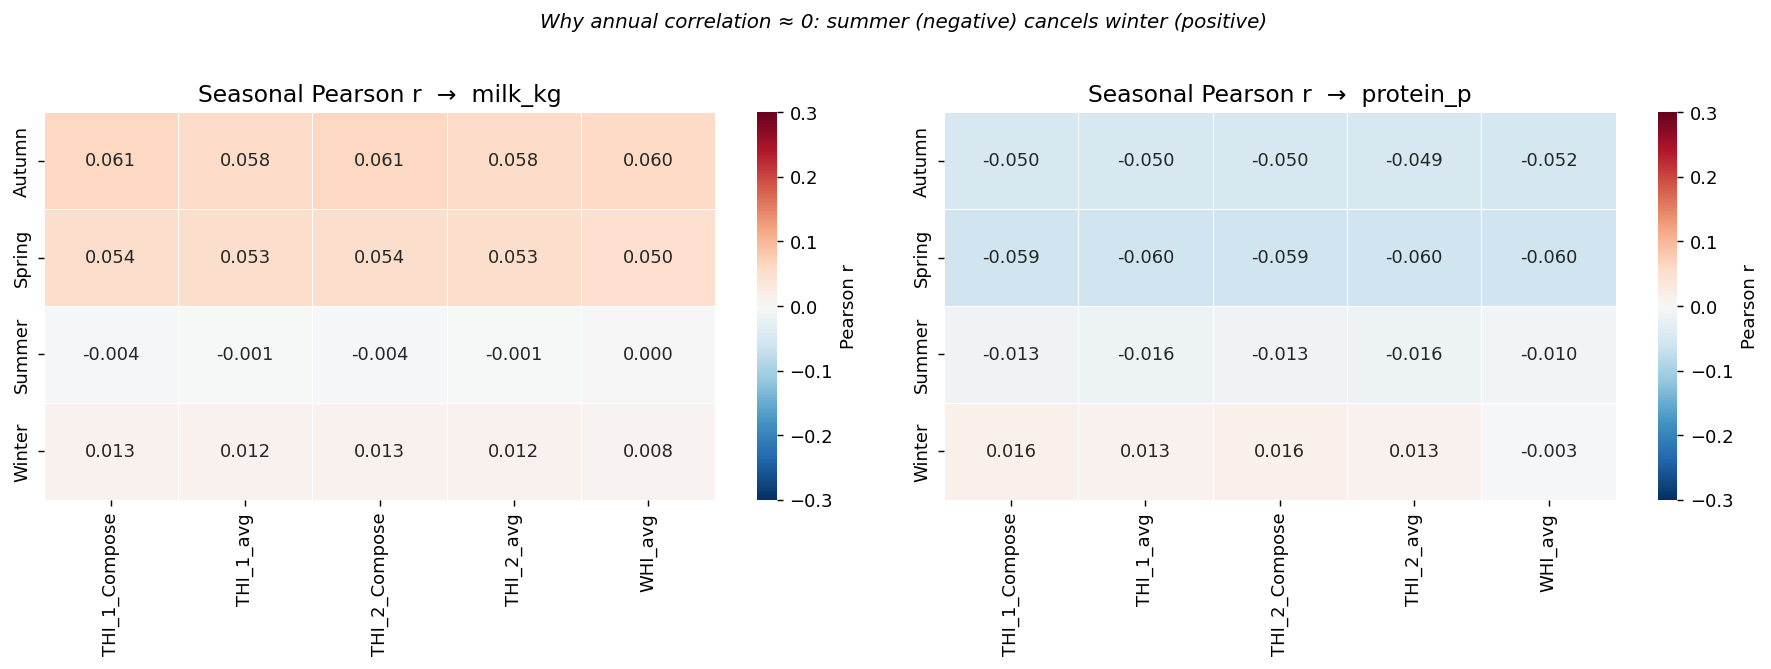

✅ Saved → seasonal_correlation_heatmap.png


In [5]:
# ── Heatmap: Pearson r per season × index (one panel per target) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tgt in zip(axes, targets):
    pivot = (
        season_corr[season_corr['target'] == tgt]
        .pivot(index='season', columns='index', values='pearson_r')
    )
    sns.heatmap(
        pivot, ax=ax,
        cmap='RdBu_r', center=0, vmin=-0.3, vmax=0.3,
        annot=True, fmt='.3f', linewidths=0.5,
        cbar_kws={'label': 'Pearson r'}
    )
    ax.set_title(f'Seasonal Pearson r  →  {tgt}', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle(
    'Why annual correlation ≈ 0: summer (negative) cancels winter (positive)',
    fontsize=11, y=1.02, style='italic'
)
plt.tight_layout()
plt.savefig('seasonal_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → seasonal_correlation_heatmap.png')

## 4. Quadratic Regression (Paper 1 Method — Costa et al., 2020)

Paper 1 includes THI as **linear + quadratic covariate** in a mixed model (Figure 1).  
Here we fit quadratic OLS per season and test whether the quadratic term is significant.

In [6]:
from numpy.polynomial.polynomial import polyfit as nppolyfit

rows_q = []
for idx in indices:
    for tgt in targets:
        clean = df[[idx, tgt, 'season']].dropna()
        x_all = clean[idx].values
        y_all = clean[tgt].values

        # --- Annual quadratic fit ---
        coeffs = np.polyfit(x_all, y_all, deg=2)  # [a, b, c]  ax²+bx+c
        y_pred = np.polyval(coeffs, x_all)
        r2_annual = r2_score(y_all, y_pred)

        rows_q.append({
            'index': idx, 'target': tgt, 'season': 'Annual',
            'a (quad)': round(coeffs[0], 6),
            'b (linear)': round(coeffs[1], 4),
            'c (intercept)': round(coeffs[2], 4),
            'R2': round(r2_annual, 4),
            'vertex_x': round(-coeffs[1] / (2 * coeffs[0]), 2) if coeffs[0] != 0 else np.nan
        })

        # --- Per-season quadratic fit ---
        for season, sg in clean.groupby('season', observed=True):
            if len(sg) < 50:
                continue
            xs = sg[idx].values
            ys = sg[tgt].values
            cs = np.polyfit(xs, ys, deg=2)
            yp = np.polyval(cs, xs)
            rows_q.append({
                'index': idx, 'target': tgt, 'season': season,
                'a (quad)': round(cs[0], 6),
                'b (linear)': round(cs[1], 4),
                'c (intercept)': round(cs[2], 4),
                'R2': round(r2_score(ys, yp), 4),
                'vertex_x': round(-cs[1] / (2 * cs[0]), 2) if cs[0] != 0 else np.nan
            })

quad_df = pd.DataFrame(rows_q)
print(quad_df.to_string(index=False))
quad_df.to_csv('quadratic_regression_results.csv', index=False)
print('\n✅ Saved → quadratic_regression_results.csv')
print('\n⚠ vertex_x = the index value where the curve peaks/troughs (breakpoint estimate)')

        index    target season  a (quad)  b (linear)  c (intercept)     R2  vertex_x
      WHI_avg   milk_kg Annual -0.000256      0.0272         9.1154 0.0034     53.25
      WHI_avg   milk_kg Winter  0.000642      0.0083         8.8582 0.0001     -6.45
      WHI_avg   milk_kg Spring -0.000204      0.0339         9.6332 0.0025     83.02
      WHI_avg   milk_kg Summer  0.002147     -0.0891        10.5084 0.0002     20.74
      WHI_avg   milk_kg Autumn  0.001290      0.0045         8.7790 0.0040     -1.75
      WHI_avg protein_p Annual  0.000059     -0.0041         4.7429 0.0043     35.15
      WHI_avg protein_p Winter -0.000068     -0.0005         4.7738 0.0000     -3.55
      WHI_avg protein_p Spring  0.000274     -0.0079         4.6938 0.0047     14.50
      WHI_avg protein_p Summer -0.000154      0.0053         4.6382 0.0002     17.22
      WHI_avg protein_p Autumn -0.000040     -0.0027         4.7735 0.0027    -34.26
    THI_1_avg   milk_kg Annual -0.000534      0.0860         6.14

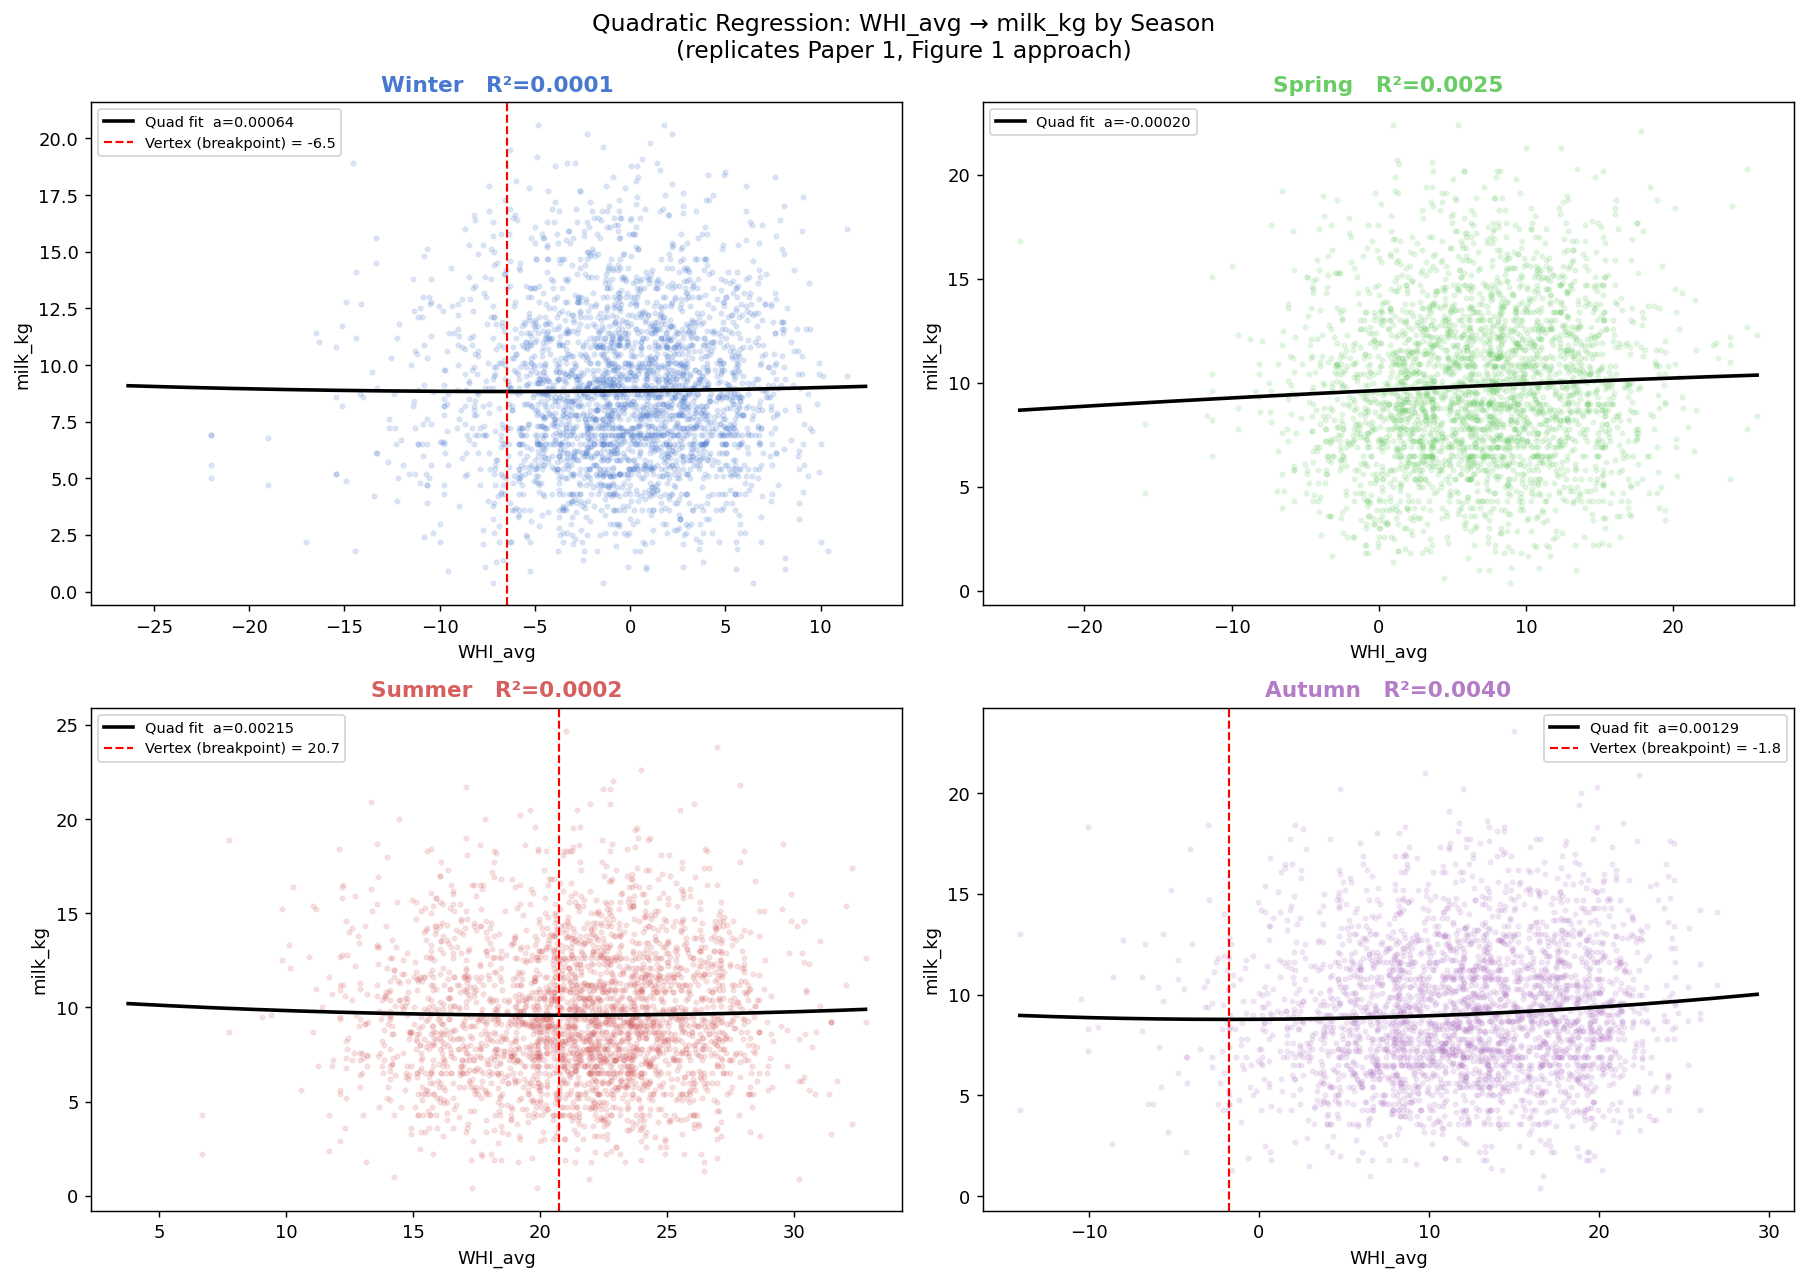

✅ Saved → quadratic_regression_by_season.png


In [7]:
# ── Plot: quadratic fit per season for WHI_avg → milk_kg (Figure 1 equivalent) ─
idx_plot = 'WHI_avg'
tgt_plot = 'milk_kg'

seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, season in zip(axes.flat, seasons):
    sub = df[df['season'] == season][[idx_plot, tgt_plot]].dropna()
    if len(sub) < 50:
        ax.set_title(f'{season} — insufficient data')
        continue

    xs = sub[idx_plot].values
    ys = sub[tgt_plot].values
    cs = np.polyfit(xs, ys, deg=2)

    # scatter (sample for speed)
    sample = sub.sample(min(3000, len(sub)), random_state=42)
    ax.scatter(sample[idx_plot], sample[tgt_plot],
               alpha=0.15, s=6, color=season_colors[season])

    # quadratic curve
    xfit = np.linspace(xs.min(), xs.max(), 300)
    ax.plot(xfit, np.polyval(cs, xfit), color='black', lw=2,
            label=f'Quad fit  a={cs[0]:.5f}')

    # vertex
    if cs[0] != 0:
        vx = -cs[1] / (2 * cs[0])
        vy = np.polyval(cs, vx)
        if xs.min() <= vx <= xs.max():
            ax.axvline(vx, color='red', lw=1.2, ls='--',
                       label=f'Vertex (breakpoint) = {vx:.1f}')

    r2 = r2_score(ys, np.polyval(cs, xs))
    ax.set_title(f'{season}   R²={r2:.4f}', fontsize=12,
                 color=season_colors[season], fontweight='bold')
    ax.set_xlabel(idx_plot)
    ax.set_ylabel(tgt_plot)
    ax.legend(fontsize=8)

plt.suptitle(f'Quadratic Regression: {idx_plot} → {tgt_plot} by Season\n'
             '(replicates Paper 1, Figure 1 approach)',
             fontsize=13)
plt.tight_layout()
plt.savefig('quadratic_regression_by_season.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → quadratic_regression_by_season.png')

## 5. Index Class Analysis — Low / Mid / High

Both papers classify THI into 3 groups using **mean ± 1 SD** and compare  
least-squares means across groups. We replicate this approach here.

In [8]:
class_results = []

for idx in indices:
    mu  = df[idx].mean()
    sd  = df[idx].std()

    df[f'{idx}_class'] = pd.cut(
        df[idx],
        bins=[-np.inf, mu - sd, mu + sd, np.inf],
        labels=['Low', 'Mid', 'High']
    )

    print(f'\n── {idx}  (mean={mu:.2f}, SD={sd:.2f}) ──────────')
    for tgt in targets:
        stats_tbl = (
            df.groupby(f'{idx}_class', observed=True)[tgt]
            .agg(['mean', 'std', 'count'])
            .rename(columns={'mean': 'Mean', 'std': 'SD', 'count': 'N'})
            .round(4)
        )
        print(f'  Target: {tgt}')
        print(stats_tbl.to_string())

        for cls, row in stats_tbl.iterrows():
            class_results.append({
                'index': idx, 'target': tgt,
                'class': cls, 'mean': row['Mean'],
                'SD': row['SD'], 'N': int(row['N'])
            })

class_df = pd.DataFrame(class_results)
class_df.to_csv('index_class_means.csv', index=False)
print('\n✅ Saved → index_class_means.csv')


── WHI_avg  (mean=10.10, SD=9.39) ──────────
  Target: milk_kg
                 Mean      SD        N
WHI_avg_class                         
Low            8.9706  3.5935   301204
Mid            9.3699  3.5661  1009185
High           9.5906  3.5207   336420
  Target: protein_p
                 Mean      SD        N
WHI_avg_class                         
Low            4.7605  0.4369   301204
Mid            4.7083  0.4343  1009185
High           4.6811  0.4298   336420

── THI_1_avg  (mean=60.61, SD=10.02) ──────────
  Target: milk_kg
                   Mean      SD       N
THI_1_avg_class                        
Low              8.9406  3.5528  313711
Mid              9.3898  3.5827  987783
High             9.5696  3.5068  345315
  Target: protein_p
                   Mean      SD       N
THI_1_avg_class                        
Low              4.7585  0.4390  313711
Mid              4.7089  0.4339  987783
High             4.6798  0.4292  345315

── THI_2_avg  (mean=60.56, SD=10.00) ─

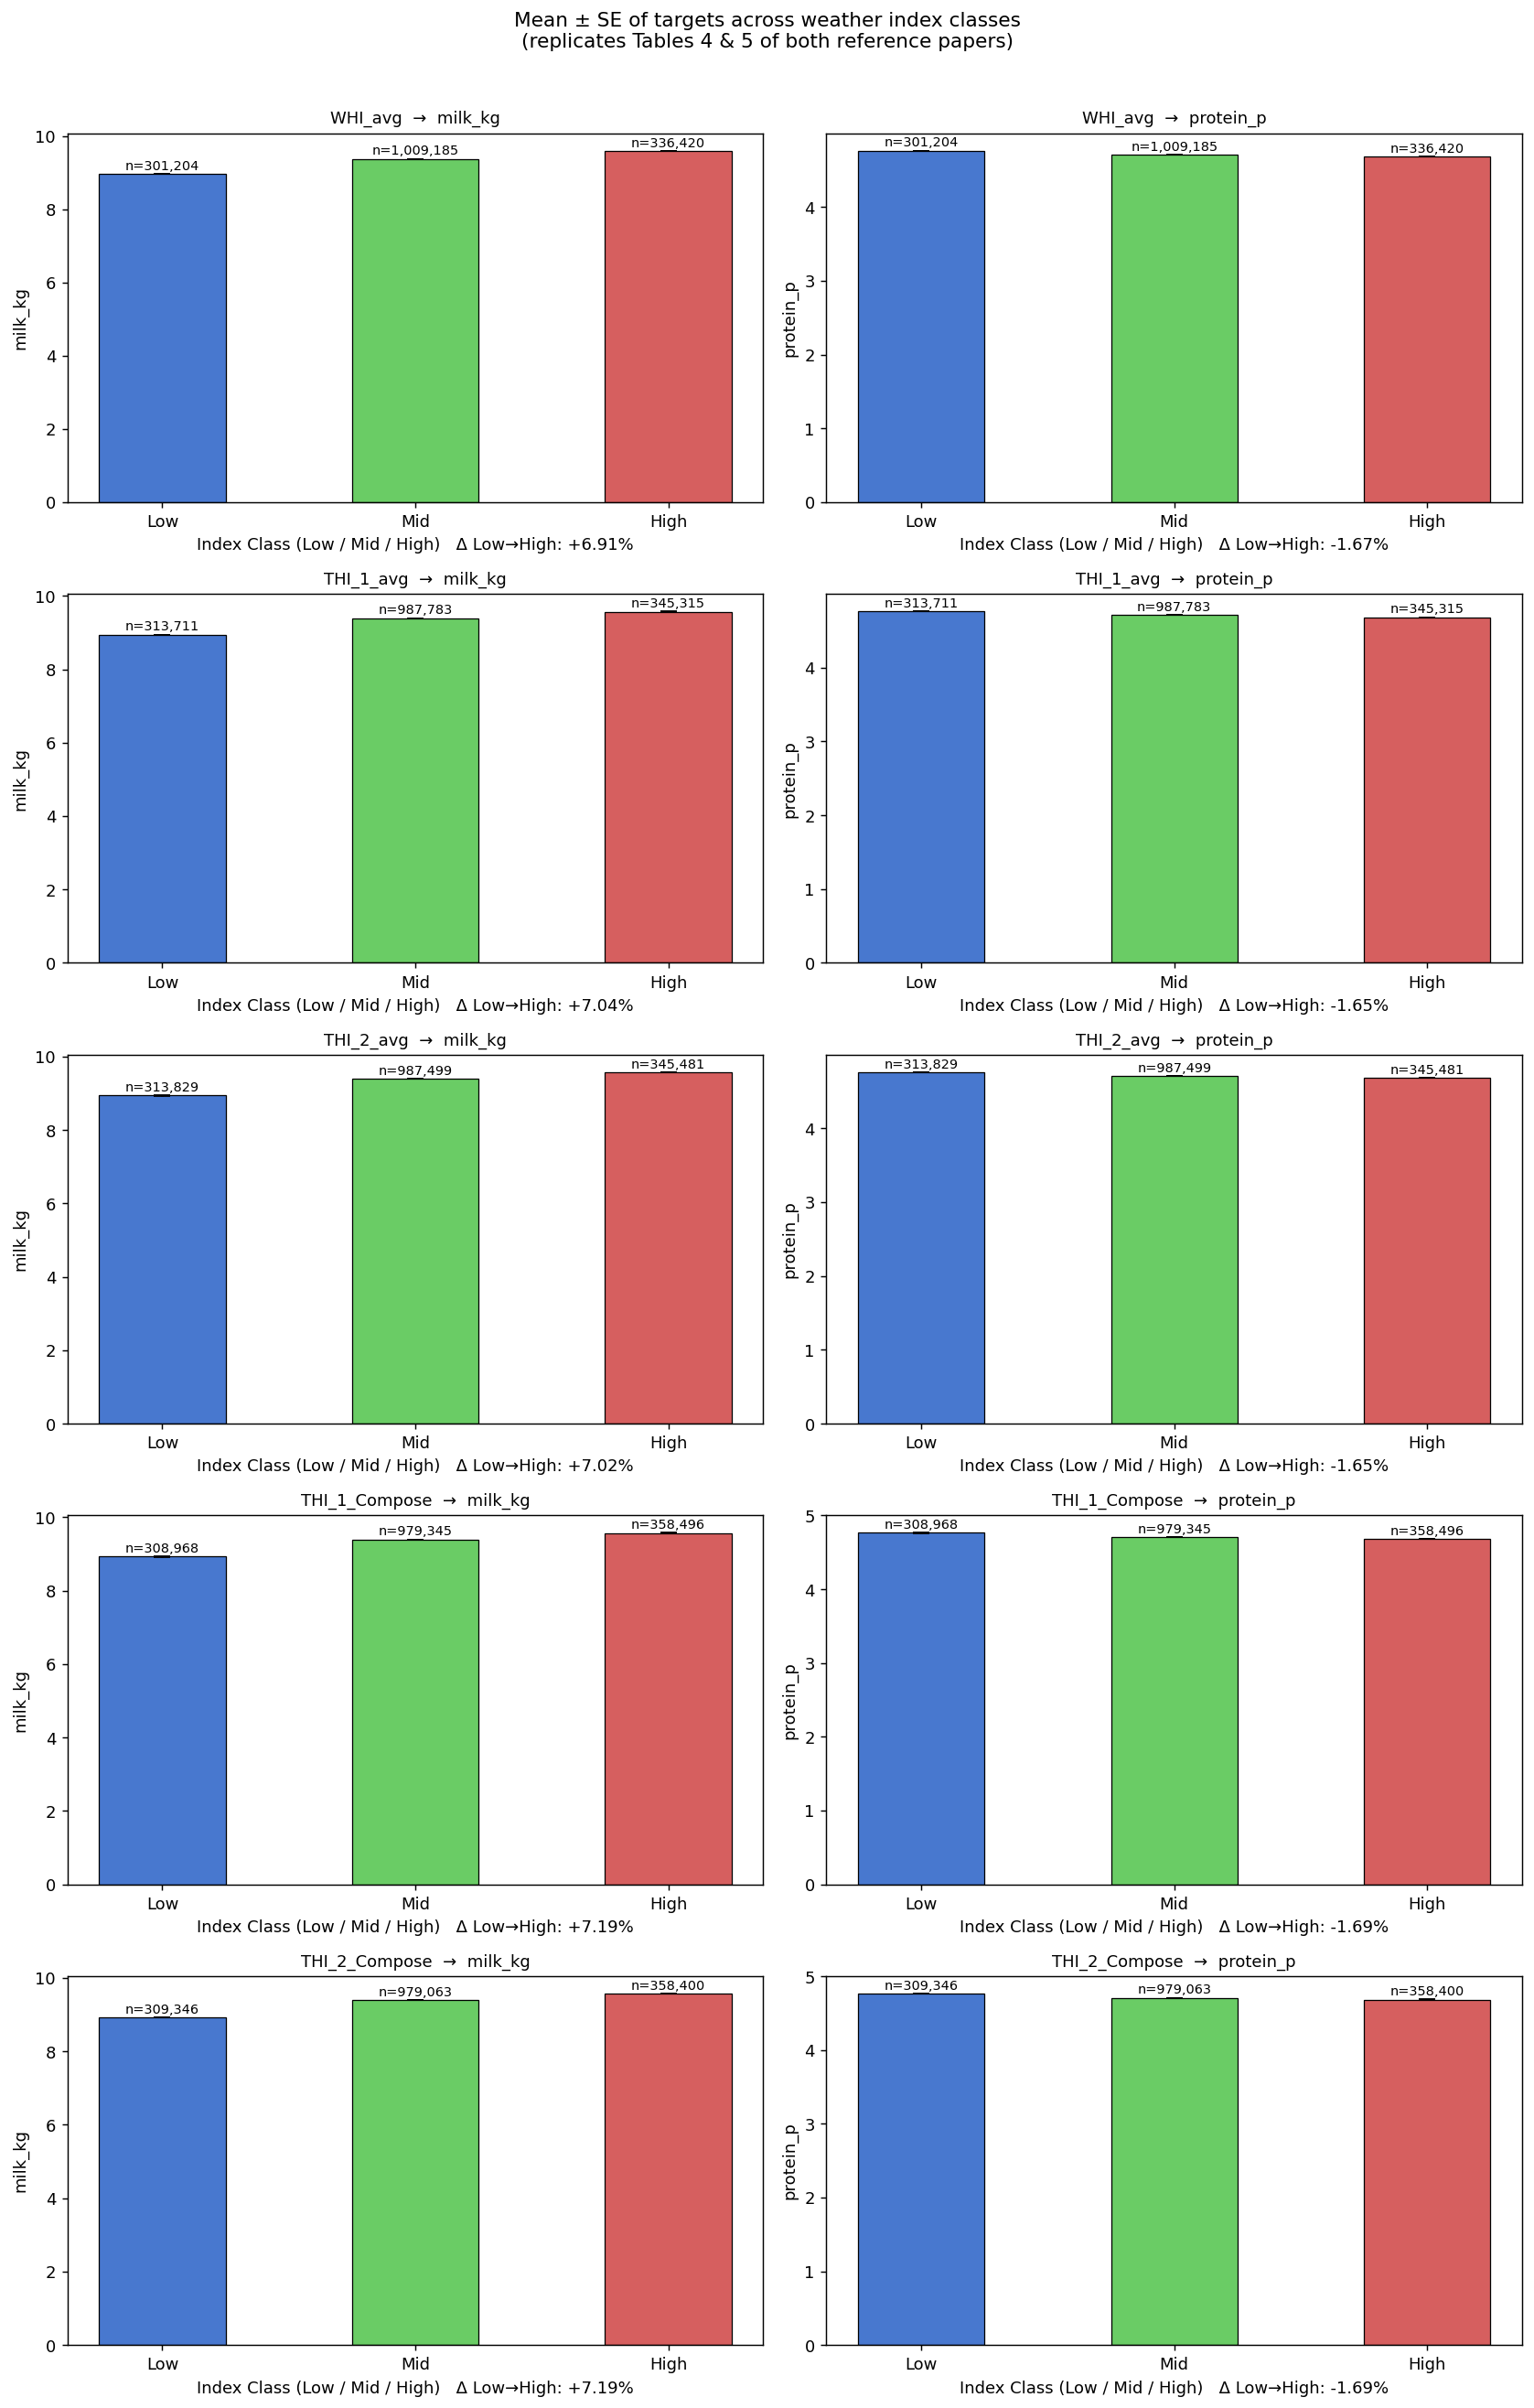

✅ Saved → index_class_bar_charts.png


In [9]:
# ── Bar chart: mean milk_kg and protein_p across Low/Mid/High classes ──────────
fig, axes = plt.subplots(len(indices), 2, figsize=(13, 4 * len(indices)))

class_colors = {'Low': '#4878CF', 'Mid': '#6ACC65', 'High': '#D65F5F'}

for row_i, idx in enumerate(indices):
    for col_i, tgt in enumerate(targets):
        ax = axes[row_i, col_i]
        sub = class_df[(class_df['index'] == idx) & (class_df['target'] == tgt)]
        bars = ax.bar(
            sub['class'], sub['mean'],
            yerr=sub['SD'] / np.sqrt(sub['N']),  # standard error
            color=[class_colors[c] for c in sub['class']],
            capsize=5, width=0.5, edgecolor='black', linewidth=0.7
        )
        # add N labels
        for bar, (_, row) in zip(bars, sub.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + bar.get_height()*0.005,
                    f'n={int(row["N"]):,}', ha='center', va='bottom', fontsize=8)
        ax.set_title(f'{idx}  →  {tgt}', fontsize=10)
        ax.set_xlabel('Index Class (Low / Mid / High)')
        ax.set_ylabel(tgt)
        # add change % annotation
        vals = sub.set_index('class')['mean']
        if 'Low' in vals and 'High' in vals and vals['Low'] != 0:
            pct = (vals['High'] - vals['Low']) / vals['Low'] * 100
            ax.set_xlabel(
                f'Index Class (Low / Mid / High)   Δ Low→High: {pct:+.2f}%'
            )

plt.suptitle('Mean ± SE of targets across weather index classes\n'
             '(replicates Tables 4 & 5 of both reference papers)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('index_class_bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → index_class_bar_charts.png')

## 6. Breakpoint / Threshold Analysis

Bernabucci et al. (2014) — cited in Paper 2 — found protein content drops at THI ≈ 65  
and fat at THI ≈ 50. We search for the breakpoint in our data using piecewise linear fit.

In [10]:
def find_breakpoint(x, y, percentile_range=(10, 90), step=1):
    """Grid search for the piecewise-linear breakpoint with best combined R²."""
    candidates = np.percentile(x, np.arange(*percentile_range, step))
    best_bp, best_r2 = None, -np.inf

    for bp in candidates:
        m1 = x < bp
        m2 = ~m1
        if m1.sum() < 20 or m2.sum() < 20:
            continue
        c1 = np.polyfit(x[m1], y[m1], 1)
        c2 = np.polyfit(x[m2], y[m2], 1)
        y_pred = np.where(m1, np.polyval(c1, x), np.polyval(c2, x))
        r2 = r2_score(y, y_pred)
        if r2 > best_r2:
            best_r2, best_bp = r2, bp
    return best_bp, best_r2


bp_results = []
for idx in indices:
    for tgt in targets:
        clean = df[[idx, tgt]].dropna()
        x = clean[idx].values
        y = clean[tgt].values
        bp, r2 = find_breakpoint(x, y)
        bp_results.append({'index': idx, 'target': tgt,
                            'breakpoint': round(bp, 2) if bp else np.nan,
                            'R2_piecewise': round(r2, 4)})
        print(f'{idx} → {tgt}: breakpoint = {bp:.2f}  (piecewise R² = {r2:.4f})')

bp_df = pd.DataFrame(bp_results)
bp_df.to_csv('breakpoint_results.csv', index=False)
print('\n✅ Saved → breakpoint_results.csv')

WHI_avg → milk_kg: breakpoint = 0.63  (piecewise R² = 0.0036)
WHI_avg → protein_p: breakpoint = 5.76  (piecewise R² = 0.0046)
THI_1_avg → milk_kg: breakpoint = 49.95  (piecewise R² = 0.0041)
THI_1_avg → protein_p: breakpoint = 65.72  (piecewise R² = 0.0047)
THI_2_avg → milk_kg: breakpoint = 49.93  (piecewise R² = 0.0041)
THI_2_avg → protein_p: breakpoint = 65.67  (piecewise R² = 0.0048)
THI_1_Compose → milk_kg: breakpoint = 62.21  (piecewise R² = 0.0043)
THI_1_Compose → protein_p: breakpoint = 53.54  (piecewise R² = 0.0049)
THI_2_Compose → milk_kg: breakpoint = 62.17  (piecewise R² = 0.0043)
THI_2_Compose → protein_p: breakpoint = 53.51  (piecewise R² = 0.0049)

✅ Saved → breakpoint_results.csv


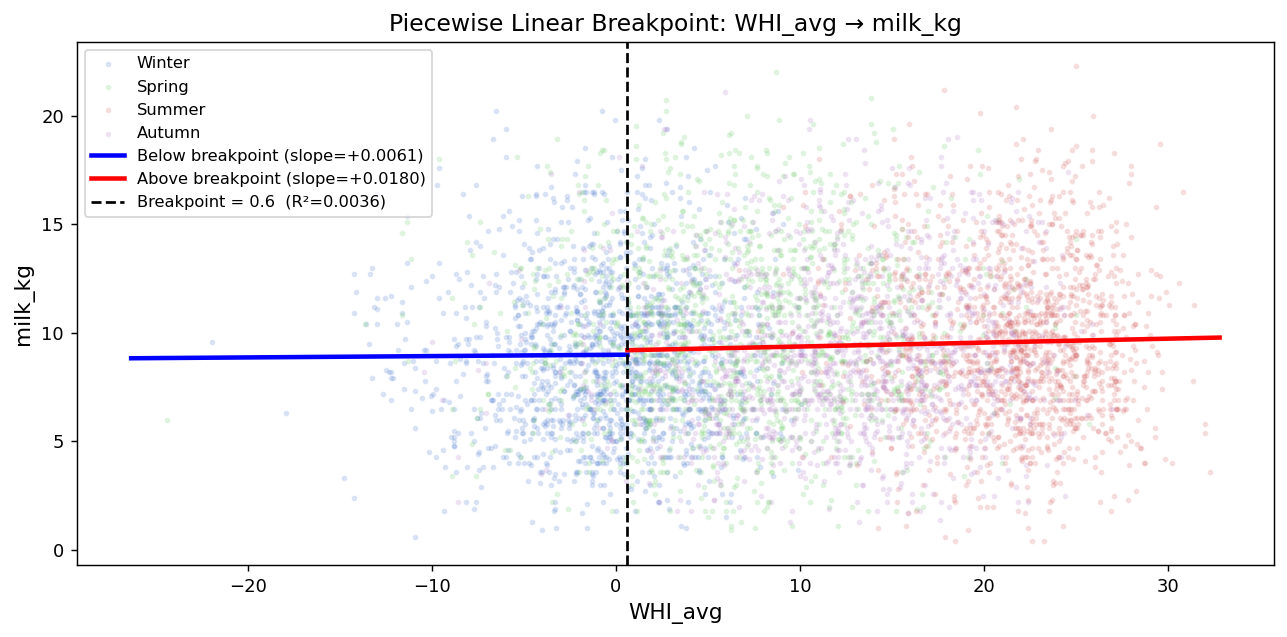

✅ Saved → breakpoint_WHI_milk.png


In [11]:
# ── Plot piecewise fit for WHI_avg → milk_kg ───────────────────────────────────
idx_plot = 'WHI_avg'
tgt_plot = 'milk_kg'

clean = df[[idx_plot, tgt_plot]].dropna()
x = clean[idx_plot].values
y = clean[tgt_plot].values
bp, r2 = find_breakpoint(x, y)

c1 = np.polyfit(x[x < bp], y[x < bp], 1)
c2 = np.polyfit(x[x >= bp], y[x >= bp], 1)

xfit1 = np.linspace(x.min(), bp, 200)
xfit2 = np.linspace(bp, x.max(), 200)

fig, ax = plt.subplots(figsize=(10, 5))

# scatter by season
for season, grp in df.groupby('season', observed=True):
    sub = grp[[idx_plot, tgt_plot]].dropna().sample(min(1500, len(grp)), random_state=0)
    ax.scatter(sub[idx_plot], sub[tgt_plot],
               alpha=0.15, s=5, color=season_colors[season], label=season)

ax.plot(xfit1, np.polyval(c1, xfit1), 'b-', lw=2.5,
        label=f'Below breakpoint (slope={c1[0]:+.4f})')
ax.plot(xfit2, np.polyval(c2, xfit2), 'r-', lw=2.5,
        label=f'Above breakpoint (slope={c2[0]:+.4f})')
ax.axvline(bp, color='black', ls='--', lw=1.5,
           label=f'Breakpoint = {bp:.1f}  (R²={r2:.4f})')

ax.set_xlabel(idx_plot, fontsize=12)
ax.set_ylabel(tgt_plot, fontsize=12)
ax.set_title(f'Piecewise Linear Breakpoint: {idx_plot} → {tgt_plot}', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('breakpoint_WHI_milk.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → breakpoint_WHI_milk.png')

## 7. Monthly Correlation Trend

Reproduces the logic of **Paper 1, Figure 2B** — shows how the sign of the  
correlation between the weather index and milk yield flips across months.

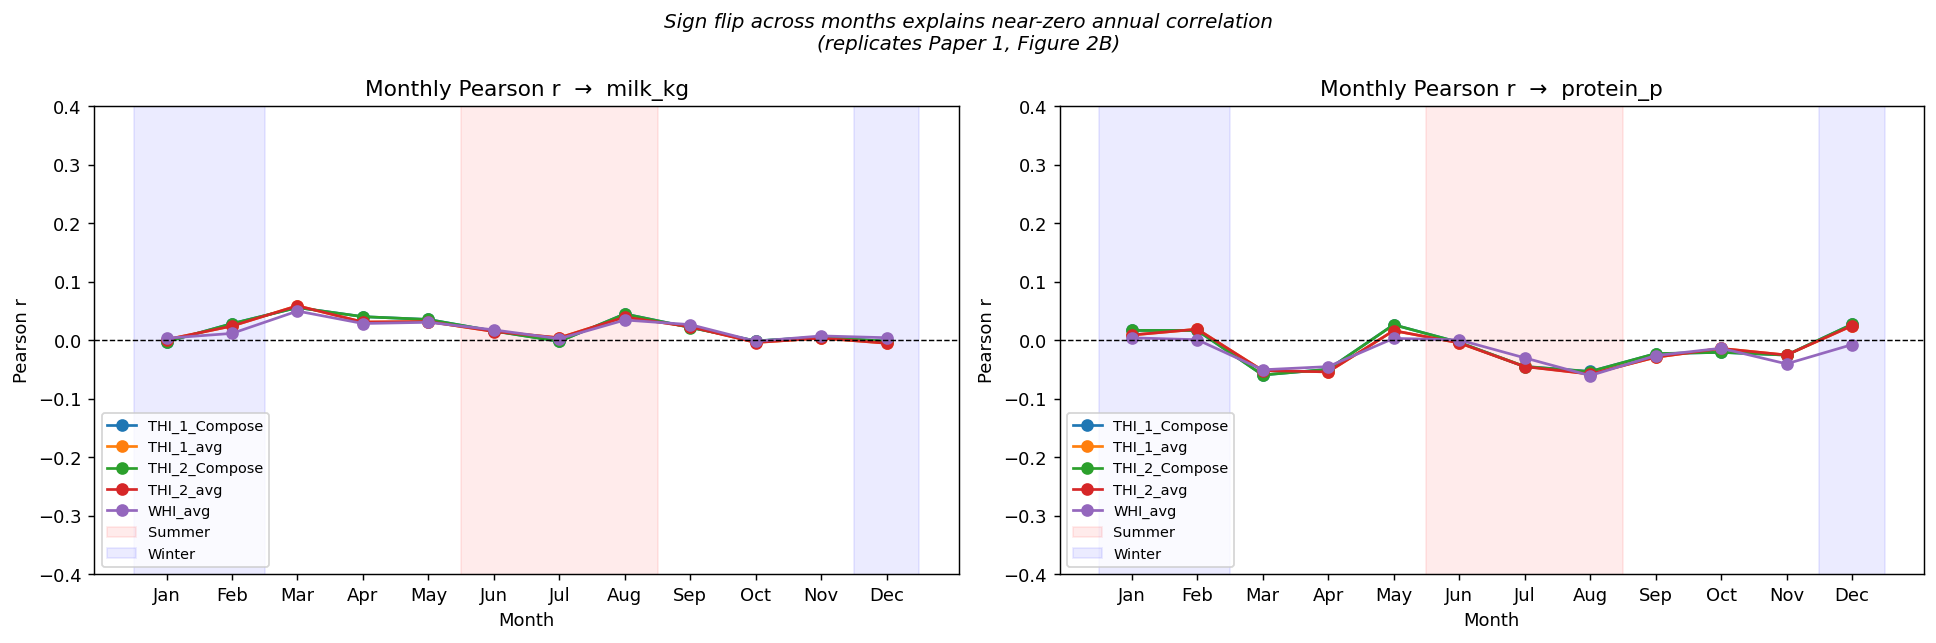

✅ Saved → monthly_correlation_trend.png


In [12]:
month_rows = []
for m in range(1, 13):
    sub = df[df['month'] == m]
    for idx in indices:
        for tgt in targets:
            clean = sub[[idx, tgt]].dropna()
            if len(clean) < 30:
                continue
            r, p = stats.pearsonr(clean[idx], clean[tgt])
            month_rows.append({'month': m, 'index': idx, 'target': tgt,
                               'pearson_r': round(r, 4), 'p': round(p, 6)})

monthly_df = pd.DataFrame(month_rows)
monthly_df.to_csv('monthly_correlations.csv', index=False)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, tgt in zip(axes, targets):
    sub = monthly_df[monthly_df['target'] == tgt]
    for idx, grp in sub.groupby('index'):
        grp = grp.sort_values('month')
        ax.plot(grp['month'], grp['pearson_r'], marker='o', label=idx)

    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.fill_between([5.5, 8.5], -1, 1, alpha=0.08, color='red', label='Summer')
    ax.fill_between([11.5, 12.5], -1, 1, alpha=0.08, color='blue')
    ax.fill_between([0.5, 2.5], -1, 1, alpha=0.08, color='blue', label='Winter')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_xlabel('Month')
    ax.set_ylabel('Pearson r')
    ax.set_title(f'Monthly Pearson r  →  {tgt}', fontsize=12)
    ax.legend(fontsize=8, loc='lower left')
    ax.set_ylim(-0.4, 0.4)

plt.suptitle('Sign flip across months explains near-zero annual correlation\n'
             '(replicates Paper 1, Figure 2B)', fontsize=11, style='italic')
plt.tight_layout()
plt.savefig('monthly_correlation_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → monthly_correlation_trend.png')

## 8. Summary Table

Concise view of all methods and their key outputs.

In [13]:
print('=== SEASON-STRATIFIED PEARSON r (milk_kg) ===')
print(
    season_corr[season_corr['target']=='milk_kg']
    [['season','index','pearson_r','pearson_p']]
    .pivot(index='season', columns='index', values='pearson_r')
    .round(4)
    .to_string()
)

print('\n=== BREAKPOINTS ===')
print(bp_df.to_string(index=False))

print('\n=== QUADRATIC VERTEX (annual) — index value where curve peaks/troughs ===')
print(
    quad_df[quad_df['season']=='Annual']
    [['index','target','a (quad)','vertex_x','R2']]
    .to_string(index=False)
)

=== SEASON-STRATIFIED PEARSON r (milk_kg) ===
index   THI_1_Compose  THI_1_avg  THI_2_Compose  THI_2_avg  WHI_avg
season                                                             
Autumn         0.0611     0.0584         0.0610     0.0583   0.0603
Spring         0.0538     0.0526         0.0537     0.0526   0.0502
Summer        -0.0036    -0.0008        -0.0038    -0.0009   0.0002
Winter         0.0129     0.0121         0.0128     0.0121   0.0078

=== BREAKPOINTS ===
        index    target  breakpoint  R2_piecewise
      WHI_avg   milk_kg        0.63        0.0036
      WHI_avg protein_p        5.76        0.0046
    THI_1_avg   milk_kg       49.95        0.0041
    THI_1_avg protein_p       65.72        0.0047
    THI_2_avg   milk_kg       49.93        0.0041
    THI_2_avg protein_p       65.67        0.0048
THI_1_Compose   milk_kg       62.21        0.0043
THI_1_Compose protein_p       53.54        0.0049
THI_2_Compose   milk_kg       62.17        0.0043
THI_2_Compose protein_p  

In [15]:
df.head()

,Farm_Code,Animal_ID,dtb,dtc,dtt,parity,milk_kg,fat_p,protein_p,cells,...,WHI_avg_lag3,THI_1_Compose,THI_2_Compose,month,season,WHI_avg_class,THI_1_avg_class,THI_2_avg_class,THI_1_Compose_class,THI_2_Compose_class
0,521513,IT003900148399,2019-04-04,2021-08-21,2021-09-06,1,7.9,6.23,5.03,52,...,17.053,68.5548,68.4676,9,Autumn,Mid,Mid,Mid,Mid,Mid
1,521513,IT003900148399,2019-04-04,2021-08-21,2021-10-11,1,10.9,7.16,4.53,149,...,7.748,55.0800,55.0476,10,Autumn,Mid,Mid,Mid,Mid,Mid
2,521513,IT003900148399,2019-04-04,2021-08-21,2021-12-20,1,8.2,8.99,4.65,3107,...,-8.988,35.9156,35.9142,12,Winter,Low,Low,Low,Low,Low
3,521513,IT003900148399,2019-04-04,2021-08-21,2022-01-17,1,11.7,7.77,4.63,48,...,-9.386,41.1856,41.1750,1,Winter,Low,Low,Low,Low,Low
4,521513,IT003900148399,2019-04-04,2021-08-21,2022-02-16,1,10.1,7.10,4.70,41,...,-6.115,40.6844,40.6786,2,Winter,Low,Low,Low,Low,Low


In [16]:
farm_day = df.groupby(['Farm_Code', 'dtt']).agg({
    'milk_kg': 'mean',
    'THI_1_avg': 'first',
    'WHI_avg': 'first',
    'season': 'first'
}).reset_index()

farm_day.groupby('season').apply(
    lambda g: stats.pearsonr(g['THI_1_avg'], g['milk_kg'])[0]
)

season
Winter    0.022744
Spring    0.050312
Summer   -0.029219
Autumn    0.110908
dtype: float64

In [17]:
df['THI_lag1'] = df.groupby('Animal_ID')['THI_1_avg'].shift(1)
df['THI_lag3_avg'] = df.groupby('Animal_ID')['THI_1_avg'].rolling(3).mean().shift(1)

TypeError: incompatible index of inserted column with frame index